# 1. Single-qubit Simulations
## 1.1. Single-qubit Simulations using QuTip - Amplitude Damping + Dephasing
We do simulations for the Amplitude Damping and Dephasing Noise Channels and find T1 and T2. Here, no resonant drive is assumed.

Estimated T1: 1.84s
Estimated T2: 2.86s


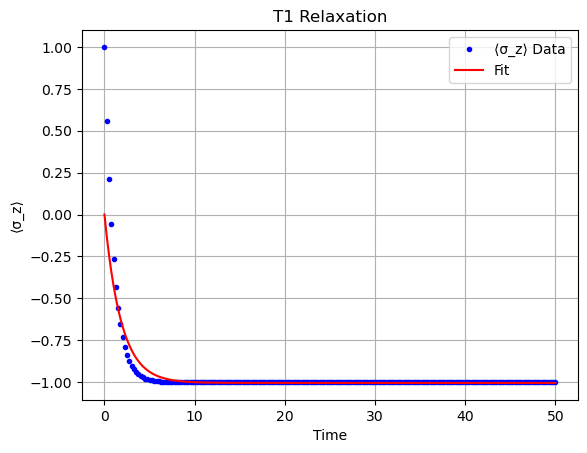

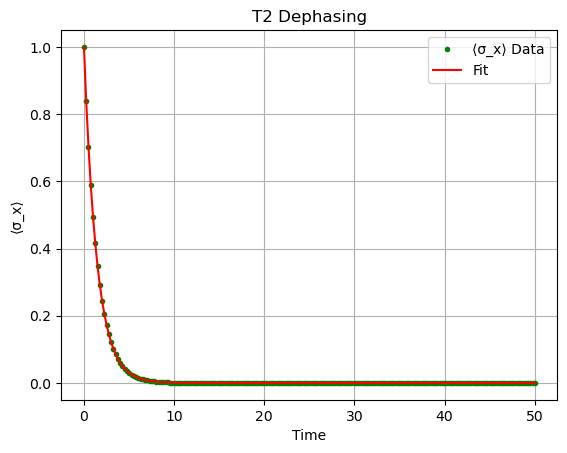

In [81]:
# Defining Basics
import numpy as np
from qutip import mesolve, Qobj
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

######### Definng quantum states as density matrices #########
Ground_state = Qobj([[0, 0], [0, 1]]) # |1><1|
Excited_state = Qobj([[1, 0], [0, 0]]) # |0><0|


######### Defining Pauli operators #########
sigma_x = Qobj([[0, 1], [1, 0]])
sigma_y = Qobj([[0, -1j], [1j, 0]])
sigma_z = Qobj([[1, 0], [0, -1]])
sigma_minus = Qobj([[0, 0], [1, 0]])


######### Density Matrix ######### 
# We can take an arbitrary matrix too but to find T_1 and T_2
# there are 2 inital density matrices that we most care about:
rho_initial_T1 = Qobj(Excited_state) # To find T_1, we let this state relax (Inversion Recovery)
rho_initial_T2 = Qobj(0.5*np.ones((2, 2), dtype=complex)) # T₂ characterizes how long phase coherence between 
# quantum states is maintained. That coherence lives in the off-diagonal elements of the 
# qubit’s density matrix — and these are only nonzero if the system starts in a superposition 
# of energy eigenstates, here (|0> + |1>)/sqrt(2).
# If we start in ∣1⟩, there's no initial phase coherence to lose — you’ll only see population decay (T₁).
# If we start in (∣0⟩+∣1⟩)/sqrt(2), the system starts with maximum coherence, and you can directly observe the decay of that coherence over time.


######### Krauss and Lindblad Operators for Spontaneous Amplitude Damping (Emission Channel) #########
# Parameters
p = 1         # Prob of a transition occuring = gamma * dt
gamma_AD = 1     # spontaneous emisson rate
hbar = 1      # set to 1
# Krauss Operators
K0 = np.sqrt(1-p) * Ground_state
K1 = np.sqrt(p) * sigma_minus
# Lindbladian
L1_AD = Qobj(np.sqrt(gamma_AD*hbar) * sigma_minus)


######### Krauss and Lindblad Operators for Dephasing Channel #########
# Parameters
gamma_DC = 0.1  # Smaller dephasing than ampl. damping 
# Krauss Operators
K0 = np.sqrt(1-p) * Ground_state
K1 = np.sqrt(p) * Excited_state + np.sqrt(p) * Ground_state # = np.sqrt(p) * sigma_z
L1_DC = Qobj(np.sqrt(gamma_DC*hbar) * sigma_z) # 1 qubit dephasing quantum channel


######### Solving the Lindblad Master Equation (ODE Solver) #########
T_max = 50
timesteps = 200
tlist = np.linspace(0, T_max, timesteps)

H = Qobj(np.zeros((2, 2), dtype=complex))  # Zero Hamiltonian for pure noise

result_T1 = mesolve(H, rho_initial_T1, tlist, [L1_AD, L1_DC], [sigma_z]) # For T1 with both AD and DC
result_T2 = mesolve(H, rho_initial_T2, tlist, [L1_AD, L1_DC], [sigma_x]) # For T2 with both AD and DC


######### Simulating Dynamics #########
# Extracting T1 and T2
def fit_T1(t, Meq, T1):
    return Meq * (-1+np.exp(-t / T1))

def fit_T2(t, M0, T2):
    return M0 * np.exp(-2 * t / T2)

# Fit data
popt_T1, _ = curve_fit(fit_T1, tlist, result_T1.expect[0], p0=[1.0, 10.0])
popt_T2, _ = curve_fit(fit_T2, tlist, result_T2.expect[0], p0=[1.0, 10.0])
Meq, T1_fit = popt_T1
M0, T2_fit = popt_T2

# Print results
print(f"Estimated T1: {T1_fit:.2f}s")
print(f"Estimated T2: {T2_fit:.2f}s")

# Plot T1 Decay
plt.figure()
plt.plot(tlist, result_T1.expect[0], 'b.', label='⟨σ_z⟩ Data')
plt.plot(tlist, fit_T1(tlist, *popt_T1), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_z⟩')
plt.title('T1 Relaxation')
plt.legend()
plt.grid(True)

# Plot T2 Decay
plt.figure()
plt.plot(tlist, result_T2.expect[0], 'g.', label='⟨σ_x⟩ Data')
plt.plot(tlist, fit_T2(tlist, *popt_T2), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_x⟩')
plt.title('T2 Dephasing')
plt.legend()
plt.grid(True)

plt.show()

This is the orginal version but the convention is $|0\rangle$ is the ground state, not excited, so I change that below for the same code as above. But it doesnt work unless I change sigma_minus to be `sigma_minus = Qobj([[0, 1], [0, 0]])`.

##  1.2. Single-qubit Simulations using correct convention - Amplitude Damping + Dephasing

Estimated T1: 1.84s
Estimated T2: 2.86s


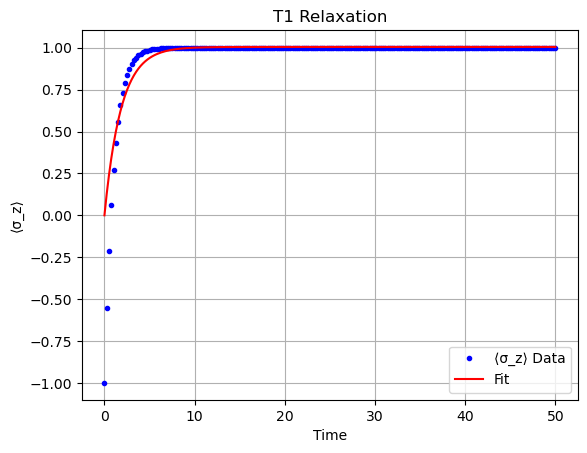

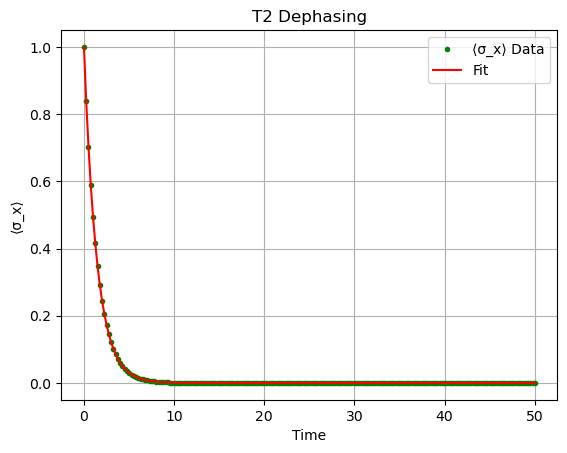

In [104]:
# Defining Basics
import numpy as np
from qutip import mesolve, Qobj
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

######### Definng quantum states as density matrices #########
Ground_state = Qobj([[1, 0], [0, 0]]) # |0⟩⟨0| (σ_z = +1 eigenstate)
Excited_state = Qobj([[0, 0], [0, 1]]) # |1⟩⟨1| (σ_z = -1 eigenstate)


######### Defining Pauli operators #########
sigma_x = Qobj([[0, 1], [1, 0]])
sigma_y = Qobj([[0, -1j], [1j, 0]])
sigma_z = Qobj([[1, 0], [0, -1]])
sigma_minus = Qobj([[0, 1], [0, 0]]) # Was Qobj([[0, 0], [1, 0]])


######### Density Matrix ######### 
# We can take an arbitrary matrix too but to find T_1 and T_2
# there are 2 inital density matrices that we most care about:
rho_initial_T1 = Qobj(Excited_state) # To find T_1, we let this state relax (Inversion Recovery)
rho_initial_T2 = Qobj(0.5*np.ones((2, 2), dtype=complex)) # T₂ characterizes how long phase coherence between 
# quantum states is maintained. That coherence lives in the off-diagonal elements of the 
# qubit’s density matrix — and these are only nonzero if the system starts in a superposition 
# of energy eigenstates, here (|0> + |1>)/sqrt(2).
# If we start in ∣1⟩, there's no initial phase coherence to lose — you’ll only see population decay (T₁).
# If we start in (∣0⟩+∣1⟩)/sqrt(2), the system starts with maximum coherence, and you can directly observe the decay of that coherence over time.


######### Krauss and Lindblad Operators for Spontaneous Amplitude Damping (Emission Channel) #########
# Parameters
gamma_AD = 1  # spontaneous emisson rate
hbar = 1      # set to 1
# Lindbladian
L1_AD = Qobj(np.sqrt(gamma_AD*hbar) * sigma_minus)


######### Krauss and Lindblad Operators for Dephasing Channel #########
# Parameters
gamma_DC = 0.1  # Smaller dephasing than ampl. damping   
L1_DC = Qobj(np.sqrt(gamma_DC*hbar) * sigma_z) # 1 qubit dephasing quantum channel


######### Solving the Lindblad Master Equation (ODE Solver) #########
T_max = 50
timesteps = 200
tlist = np.linspace(0, T_max, timesteps)

H = Qobj(np.zeros((2, 2), dtype=complex))  # Zero Hamiltonian for pure noise

result_T1 = mesolve(H, rho_initial_T1, tlist, [L1_AD, L1_DC], [sigma_z]) # For T1 with both AD and DC
result_T2 = mesolve(H, rho_initial_T2, tlist, [L1_AD, L1_DC], [sigma_x]) # For T2 with both AD and DC


######### Simulating Dynamics #########
# Extracting T1 and T2
def fit_T1(t, Meq, T1):
    return Meq * (1 - np.exp(-t / T1)) # If I choose 0 as excited state, then use Meq*(-1+np.exp(-t / T1)).

def fit_T2(t, M0, T2):
    return M0 * np.exp(-2 * t / T2)

# Fit data
popt_T1, _ = curve_fit(fit_T1, tlist, result_T1.expect[0], p0=[1.0, 1.0])
popt_T2, _ = curve_fit(fit_T2, tlist, result_T2.expect[0], p0=[1.0, 10.0])
Meq, T1_fit = popt_T1
M0, T2_fit = popt_T2

# Print results
print(f"Estimated T1: {T1_fit:.2f}s")
print(f"Estimated T2: {T2_fit:.2f}s")

# Plot T1 Decay
plt.figure()
plt.plot(tlist, result_T1.expect[0], 'b.', label='⟨σ_z⟩ Data')
plt.plot(tlist, fit_T1(tlist, *popt_T1), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_z⟩')
plt.title('T1 Relaxation')
plt.legend()
plt.grid(True)

# Plot T2 Decay
plt.figure()
plt.plot(tlist, result_T2.expect[0], 'g.', label='⟨σ_x⟩ Data')
plt.plot(tlist, fit_T2(tlist, *popt_T2), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_x⟩')
plt.title('T2 Dephasing')
plt.legend()
plt.grid(True)

plt.show()

We find that $T_2 \leq 2T_1$, as expected. The upper bound on $T_2$ is $T_2 = 2T_1$ when there is no dephasing. We look at that next.

## 1.3. Single-qubit Simulations using QuTip - Amplitude Damping $(T_2 = 2T_1)$
We do simulations for the Amplitude Damping only and find T1 and T2. Here, no resonant drive is assumed.

Estimated T1: 1.84s
Estimated T2: 4.00s


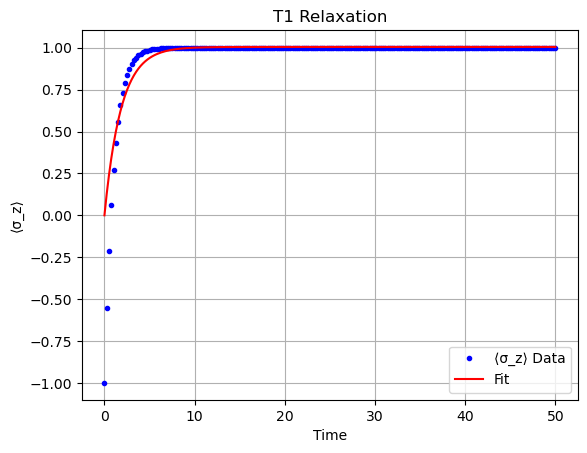

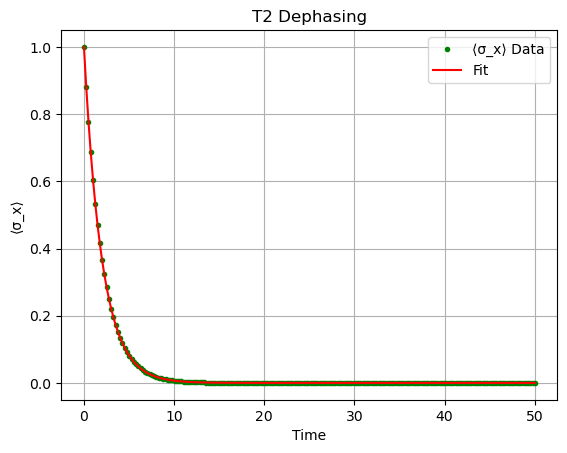

In [107]:
# Defining Basics
import numpy as np
from qutip import mesolve, Qobj
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

######### Definng quantum states as density matrices #########
Ground_state = Qobj([[1, 0], [0, 0]]) # |0⟩⟨0| (σ_z = +1 eigenstate)
Excited_state = Qobj([[0, 0], [0, 1]]) # |1⟩⟨1| (σ_z = -1 eigenstate)


######### Defining Pauli operators #########
sigma_x = Qobj([[0, 1], [1, 0]])
sigma_y = Qobj([[0, -1j], [1j, 0]])
sigma_z = Qobj([[1, 0], [0, -1]])
sigma_minus = Qobj([[0, 1], [0, 0]]) # Was Qobj([[0, 0], [1, 0]])


######### Density Matrix ######### 
# We can take an arbitrary matrix too but to find T_1 and T_2
# there are 2 inital density matrices that we most care about:
rho_initial_T1 = Qobj(Excited_state) # To find T_1, we let this state relax (Inversion Recovery)
rho_initial_T2 = Qobj(0.5*np.ones((2, 2), dtype=complex)) # T₂ characterizes how long phase coherence between 
# quantum states is maintained. That coherence lives in the off-diagonal elements of the 
# qubit’s density matrix — and these are only nonzero if the system starts in a superposition 
# of energy eigenstates, here (|0> + |1>)/sqrt(2).
# If we start in ∣1⟩, there's no initial phase coherence to lose — you’ll only see population decay (T₁).
# If we start in (∣0⟩+∣1⟩)/sqrt(2), the system starts with maximum coherence, and you can directly observe the decay of that coherence over time.


######### Krauss and Lindblad Operators for Spontaneous Amplitude Damping (Emission Channel) #########
# Parameters
gamma_AD = 1  # spontaneous emisson rate
hbar = 1      # set to 1
# Lindbladian
L1_AD = Qobj(np.sqrt(gamma_AD*hbar) * sigma_minus)

######### Solving the Lindblad Master Equation (ODE Solver) #########
T_max = 50
timesteps = 200
tlist = np.linspace(0, T_max, timesteps)

H = Qobj(np.zeros((2, 2), dtype=complex))  # Zero Hamiltonian for pure noise

result_T1 = mesolve(H, rho_initial_T1, tlist, [L1_AD], [sigma_z]) # For T1 with both AD and DC
result_T2 = mesolve(H, rho_initial_T2, tlist, [L1_AD], [sigma_x]) # For T2 with both AD and DC


######### Simulating Dynamics #########
# Extracting T1 and T2
def fit_T1(t, Meq, T1):
    return Meq * (1 - np.exp(-t / T1)) # If I choose 0 as excited state, then use Meq*(-1+np.exp(-t / T1)).

def fit_T2(t, M0, T2):
    return M0 * np.exp(-2 * t / T2)

# Fit data
popt_T1, _ = curve_fit(fit_T1, tlist, result_T1.expect[0], p0=[1.0, 1.0])
popt_T2, _ = curve_fit(fit_T2, tlist, result_T2.expect[0], p0=[1.0, 10.0])
Meq, T1_fit = popt_T1
M0, T2_fit = popt_T2

# Print results
print(f"Estimated T1: {T1_fit:.2f}s")
print(f"Estimated T2: {T2_fit:.2f}s")

# Plot T1 Decay
plt.figure()
plt.plot(tlist, result_T1.expect[0], 'b.', label='⟨σ_z⟩ Data')
plt.plot(tlist, fit_T1(tlist, *popt_T1), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_z⟩')
plt.title('T1 Relaxation')
plt.legend()
plt.grid(True)

# Plot T2 Decay
plt.figure()
plt.plot(tlist, result_T2.expect[0], 'g.', label='⟨σ_x⟩ Data')
plt.plot(tlist, fit_T2(tlist, *popt_T2), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_x⟩')
plt.title('T2 Dephasing')
plt.legend()
plt.grid(True)

plt.show()

When there is no dephasing and we only have amplitude damping, we see that $T_2$ is maximised and reaches its upper bound, $T_2 = 2T_1$!! Now, we see that actually this is almost achieves as $2T_1=3.68s<4s$, but this is because my fit is not perfect. And if we improve the fit for $T_!$, we will find $2T_1=4s$.

## 1.4. Single-qubit Simulations without QuTip (using self-defined quantum system) - Not Working Yet

Estimated T1: 70.00s
Estimated T2: 9.87s


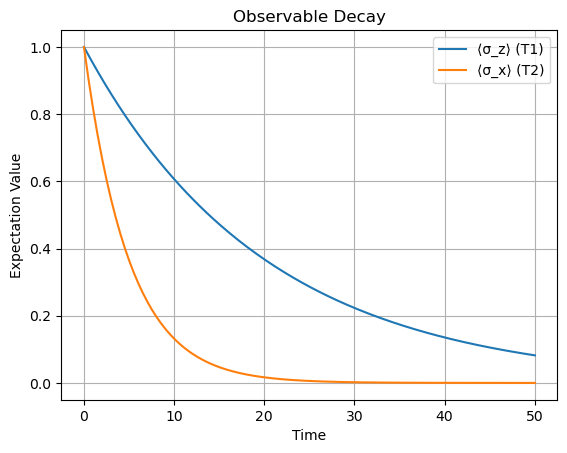

In [14]:
# Defining Basics
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

######### Definng quantum states as density matrices #########
Ground_state = np.array([[0, 0], [0, 1]], dtype=complex) # |1><1|
Excited_state = np.array([[1, 0], [0, 0]], dtype=complex) # |0><0|


######### Defining Pauli operators #########
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
sigma_minus = np.array([[0, 0], [1, 0]], dtype=complex)


######### Density Matrix ######### 
# We can take an arbitrary matrix too but to find T_1 and T_2
# there are 2 inital density matrices that we most care about:
rho_initial_T1 = Excited_state # To find T_1
rho_initial_T2 = 0.5*np.ones((2, 2), dtype=complex) # To find T_2


######### Lindblad Operators for Spontaneous Amplitude Damping (Emission Channel) #########
p = 1         # Prob of a transition occuring = gamma * dt
Gamma = 0.05     # spontaneous emisson rate
hbar = 1      # set to 1
L1_AD = np.sqrt(Gamma*hbar) * sigma_minus # Lindbladian


######### Lindblad Operators for Dephasing Channel #########
gamma = 0.1     
L1_DC = np.sqrt(gamma*hbar) * sigma_z # 1 qubit dephasing quantum channel

collapse_ops = [L1_AD, L1_DC]

######### Lindblad Master Equation for no drive (H = 0) #########
H = np.zeros((2, 2), dtype=complex)  # Zero Hamiltonian for pure noise

# To simulate the LME as a matrix DE using linear algebra, weneed to change the density
# matrix from the matrix (2X2) to a vectorised form (4X1) using flatten:

# Vectorize operator
def vec(rho):
    return rho.flatten(order='F')

# Unvectorize
def unvec(vec_rho):
    return vec_rho.reshape((2, 2), order='F')

# Define the Linbladian operator
def lindbladian(H, collapse_ops):
    I_sys = np.array([[1, 0], [0, 1]], dtype=complex)
    L = -1j * (np.kron(I_sys, H) - np.kron(H.T, I_sys))
    for c in collapse_ops:
        c_dag = c.conj().T
        L += np.kron(c, c_dag) - 0.5 * np.kron(I_sys, c_dag @ c) - 0.5 * np.kron((c_dag @ c).T, I_sys)
    return L

L = lindbladian(H, collapse_ops)

# Time evolution
def evolve_rho(rho0, L, tlist):
    rho_vec0 = vec(rho0)
    rho_t = np.zeros((len(tlist), 2, 2), dtype=complex)
    for i, t in enumerate(tlist):
        U = expm(L * t)
        rho_vec_t = U @ rho_vec0
        rho_t[i] = unvec(rho_vec_t)
    return rho_t
    

######### Solving the Lindblad Master Equation (ODE Solver) #########
rho_t_T1 = evolve_rho(rho_initial_T1, L, tlist)
rho_t_T2 = evolve_rho(rho_initial_T2, L, tlist)

# Observables
sz_expect = np.real([np.trace(rho @ sigma_z) for rho in rho_t_T1])
sx_expect = np.real([np.trace(rho @ sigma_x) for rho in rho_t_T2])

######### Simulating Dynamics #########
# Fitting functions
def fit_T1(t, Meq, T1):
    return Meq * (-1 + 2*np.exp(-t / T1))

def fit_T2(t, M0, T2):
    return M0 * np.exp(-2 * t / T2)

# Fit
popt_T1, _ = curve_fit(fit_T1, tlist, sz_expect, p0=[1.0, 10.0], bounds=([0, 1e-3], [1.5, 100]))
popt_T2, _ = curve_fit(fit_T2, tlist, sx_expect, p0=[1.0, 10.0], bounds=([0, 1e-3], [1.5, 100]))
Meq, T1_fit = popt_T1
M0, T2_fit = popt_T2

# Print results
print(f"Estimated T1: {T1_fit:.2f}s")
print(f"Estimated T2: {T2_fit:.2f}s")

# Plotting only the tehoretical curve
plt.figure()
plt.plot(tlist, sz_expect, label="⟨σ_z⟩ (T1)")
plt.plot(tlist, sx_expect, label="⟨σ_x⟩ (T2)")
plt.xlabel("Time")
plt.ylabel("Expectation Value")
plt.legend()
plt.grid(True)
plt.title("Observable Decay")
plt.show()

# 2. Two-Qubit Simulations
## 2.1. With Ampl. Damping and Dephasing Channels and no drive (H=0), no correlation betweem two qubits

Estimated T1: 1.84s
Estimated T2: 2.86s


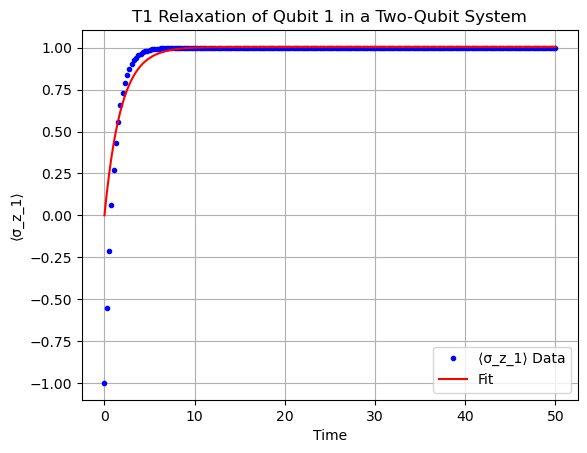

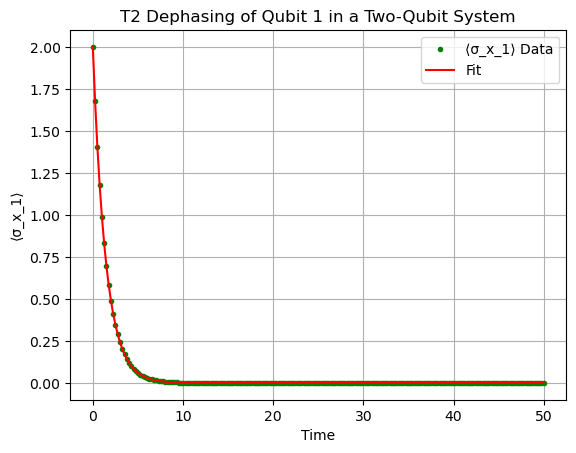

In [150]:
# Defining Basics
import numpy as np
from qutip import mesolve, Qobj, tensor
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

######### Definng quantum states as density matrices #########
Ground_state_1q = Qobj([[1, 0], [0, 0]]) # |0⟩⟨0| (σ_z = +1 eigenstate)
Excited_state_1q = Qobj([[0, 0], [0, 1]]) # |1⟩⟨1| (σ_z = -1 eigenstate)
Ground_state = tensor(Ground_state_1q, Ground_state_1q) # |00⟩⟨00| (σ_z = +1 eigenstate)
Excited_state = tensor(Excited_state_1q, Excited_state_1q) # |11⟩⟨11| (σ_z = -1 eigenstate)


######### Defining Pauli operators #########
sigma_x = Qobj([[0, 1], [1, 0]])
sigma_y = Qobj([[0, -1j], [1j, 0]])
sigma_z = Qobj([[1, 0], [0, -1]])
sigma_minus = Qobj([[0, 1], [0, 0]]) # Was Qobj([[0, 0], [1, 0]])
I = Qobj([[1, 0], [0, 1]]) # 2X2 Identity matrix

######### Defining 2-qubit Pauli operators #########
sx1 = tensor(sigma_x, I) # sigma_x on qubit 1
sx2 = tensor(I, sigma_x) # sigma_x on qubit 2
sy1 = tensor(sigma_y, I) # sigma_y on qubit 1
sy2 = tensor(I, sigma_y) # sigma_y on qubit 2
sz1 = tensor(sigma_z, I) # sigma_z on qubit 1
sz2 = tensor(I, sigma_z) # sigma_z on qubit 2
sm1 = tensor(sigma_minus, I) # sigma_minus on qubit 1
sm2 = tensor(I, sigma_minus) # sigma_minus on qubit 2

######### Density Matrix ######### 
# We can take an arbitrary matrix too but to find T_1 and T_2
# there are 2 inital density matrices that we most care about:
rho_initial_T1 = Qobj(Excited_state) # To find T_1, we let this state relax (Inversion Recovery)
rho_initial_T2 = Qobj(0.5*np.ones((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Start in (|0> + |1>)/sqrt(2) for each qubit.

######### Krauss and Lindblad Operators for Spontaneous Amplitude Damping (Emission Channel) #########
# Parameters
hbar = 1
gamma_AD_1 = 1  # spontaneous emisson rate on qubit 1
gamma_AD_2 = 1  # spontaneous emisson rate on qubit 2
L1_AD = Qobj(np.sqrt(gamma_AD_1*hbar) * sm1) # AD on qubit 1
L2_AD = Qobj(np.sqrt(gamma_AD_2*hbar) * sm2) # AD on qubit 1


######### Krauss and Lindblad Operators for Dephasing Channel #########
# Parameters
gamma_DC_1 = 0.1  # Ampl. damping on qubit 1
gamma_DC_2 = 0.1  # Ampl. damping on qubit 2
L1_DC = Qobj(np.sqrt(gamma_DC_1*hbar) * sz1) # DC on qubit 1
L2_DC = Qobj(np.sqrt(gamma_DC_2*hbar) * sz2) # DC on qubit 2


######### Solving the Lindblad Master Equation (ODE Solver) #########
T_max = 50
timesteps = 200
tlist = np.linspace(0, T_max, timesteps)

H = Qobj(np.zeros((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Zero Hamiltonian for pure noise

# We read out the qubit 1 (so use sz1, sx1)
result_T1 = mesolve(H, rho_initial_T1, tlist, [L1_AD, L2_AD, L1_DC, L2_DC], [sz1]) # For T1 with both AD and DC
result_T2 = mesolve(H, rho_initial_T2, tlist, [L1_AD, L2_AD, L1_DC, L2_DC], [sx1]) # For T2 with both AD and DC


######### Simulating Dynamics #########
# Extracting T1 and T2
def fit_T1(t, Meq, T1):
    return Meq * (1 - np.exp(-t / T1)) # If I choose 0 as excited state, then use Meq*(-1+np.exp(-t / T1)).

def fit_T2(t, M0, T2):
    return M0 * np.exp(-2 * t / T2)

# Fit data
popt_T1, _ = curve_fit(fit_T1, tlist, result_T1.expect[0], p0=[1.0, 1.0])
popt_T2, _ = curve_fit(fit_T2, tlist, result_T2.expect[0], p0=[1.0, 10.0])
Meq, T1_fit = popt_T1
M0, T2_fit = popt_T2

# Print results
print(f"Estimated T1: {T1_fit:.2f}s")
print(f"Estimated T2: {T2_fit:.2f}s")

# Plot T1 Decay
plt.figure()
plt.plot(tlist, result_T1.expect[0], 'b.', label='⟨σ_z_1⟩ Data')
plt.plot(tlist, fit_T1(tlist, *popt_T1), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_z_1⟩')
plt.title('T1 Relaxation of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

# Plot T2 Decay
plt.figure()
plt.plot(tlist, result_T2.expect[0], 'g.', label='⟨σ_x_1⟩ Data')
plt.plot(tlist, fit_T2(tlist, *popt_T2), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_x_1⟩')
plt.title('T2 Dephasing of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

plt.show()

There is no drive or cross-talk between the two qubits so we get the same result as what we got for one qubit!

## 2.2. Correlated AD and DC Noise on both qubits

Estimated T1: 0.66s
Estimated T2: 1.02s


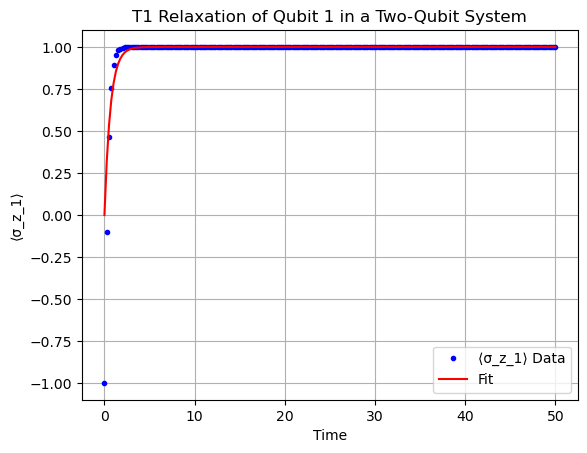

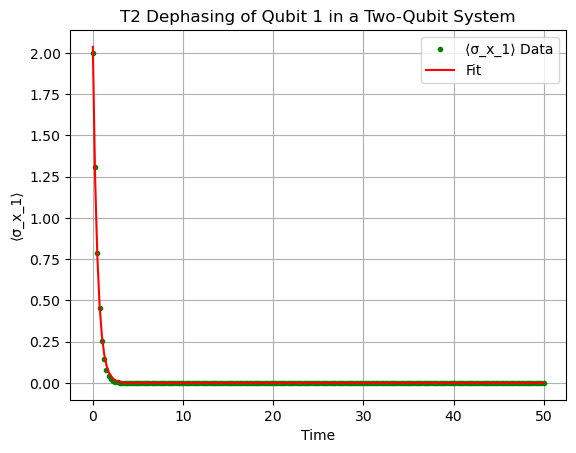

In [165]:
# Defining Basics
import numpy as np
from qutip import mesolve, Qobj, tensor
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

######### Definng quantum states as density matrices #########
Ground_state_1q = Qobj([[1, 0], [0, 0]]) # |0⟩⟨0| (σ_z = +1 eigenstate)
Excited_state_1q = Qobj([[0, 0], [0, 1]]) # |1⟩⟨1| (σ_z = -1 eigenstate)
Ground_state = tensor(Ground_state_1q, Ground_state_1q) # |00⟩⟨00| (σ_z = +1 eigenstate)
Excited_state = tensor(Excited_state_1q, Excited_state_1q) # |11⟩⟨11| (σ_z = -1 eigenstate)


######### Defining Pauli operators #########
sigma_x = Qobj([[0, 1], [1, 0]])
sigma_y = Qobj([[0, -1j], [1j, 0]])
sigma_z = Qobj([[1, 0], [0, -1]])
sigma_minus = Qobj([[0, 1], [0, 0]]) # Was Qobj([[0, 0], [1, 0]])
I = Qobj([[1, 0], [0, 1]]) # 2X2 Identity matrix

######### Defining 2-qubit Pauli operators #########
sx1 = tensor(sigma_x, I) # sigma_x on qubit 1
sx2 = tensor(I, sigma_x) # sigma_x on qubit 2
sy1 = tensor(sigma_y, I) # sigma_y on qubit 1
sy2 = tensor(I, sigma_y) # sigma_y on qubit 2
sz1 = tensor(sigma_z, I) # sigma_z on qubit 1
sz2 = tensor(I, sigma_z) # sigma_z on qubit 2
sm1 = tensor(sigma_minus, I) # sigma_minus on qubit 1
sm2 = tensor(I, sigma_minus) # sigma_minus on qubit 2

######### Density Matrix ######### 
# We can take an arbitrary matrix too but to find T_1 and T_2
# there are 2 inital density matrices that we most care about:
rho_initial_T1 = Qobj(Excited_state) # To find T_1, we let this state relax (Inversion Recovery)
rho_initial_T2 = Qobj(0.5*np.ones((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Start in (|0> + |1>)/sqrt(2) for each qubit.

######### Krauss and Lindblad Operators for Spontaneous Amplitude Damping (Emission Channel) #########
# Parameters
hbar = 1
gamma_AD_1 = 1  # spontaneous emisson rate on qubit 1
gamma_AD_2 = 1  # spontaneous emisson rate on qubit 2
L1_AD = Qobj(np.sqrt(gamma_AD_1*hbar) * (sm1+sm2)) # AD on qubit 1
L2_AD = Qobj(np.sqrt(gamma_AD_2*hbar) * (sm1+sm2)) # AD on qubit 1


######### Krauss and Lindblad Operators for Dephasing Channel #########
# Parameters
gamma_DC_1 = 0.1  # Ampl. damping on qubit 1
gamma_DC_2 = 0.1  # Ampl. damping on qubit 2
L1_DC = Qobj(np.sqrt(gamma_DC_1*hbar) * (sz1+sz2)) # DC on qubit 1
L2_DC = Qobj(np.sqrt(gamma_DC_2*hbar) * (sz1+sz2)) # DC on qubit 2


######### Solving the Lindblad Master Equation (ODE Solver) #########
T_max = 50
timesteps = 200
tlist = np.linspace(0, T_max, timesteps)

H = Qobj(np.zeros((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Zero Hamiltonian for pure noise

# We read out the qubit 1 (so use sz1, sx1)
result_T1 = mesolve(H, rho_initial_T1, tlist, [L1_AD, L2_AD, L1_DC, L2_DC], [sz1]) # For T1 with both AD and DC
result_T2 = mesolve(H, rho_initial_T2, tlist, [L1_AD, L2_AD, L1_DC, L2_DC], [sx1]) # For T2 with both AD and DC


######### Simulating Dynamics #########
# Extracting T1 and T2
def fit_T1(t, Meq, T1):
    return Meq * (1 - np.exp(-t / T1)) # If I choose 0 as excited state, then use Meq*(-1+np.exp(-t / T1)).

def fit_T2(t, M0, T2):
    return M0 * np.exp(-2 * t / T2)

# Fit data
popt_T1, _ = curve_fit(fit_T1, tlist, result_T1.expect[0], p0=[1.0, 1.0])
popt_T2, _ = curve_fit(fit_T2, tlist, result_T2.expect[0], p0=[1.0, 10.0])
Meq, T1_fit = popt_T1
M0, T2_fit = popt_T2

# Print results
print(f"Estimated T1: {T1_fit:.2f}s")
print(f"Estimated T2: {T2_fit:.2f}s")

# Plot T1 Decay
plt.figure()
plt.plot(tlist, result_T1.expect[0], 'b.', label='⟨σ_z_1⟩ Data')
plt.plot(tlist, fit_T1(tlist, *popt_T1), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_z_1⟩')
plt.title('T1 Relaxation of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

# Plot T2 Decay
plt.figure()
plt.plot(tlist, result_T2.expect[0], 'g.', label='⟨σ_x_1⟩ Data')
plt.plot(tlist, fit_T2(tlist, *popt_T2), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_x_1⟩')
plt.title('T2 Dephasing of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

plt.show()

## 2.3. Correlated AD and DC Noise on 1st qubit only

Estimated T1: 1.36s
Estimated T2: 2.02s


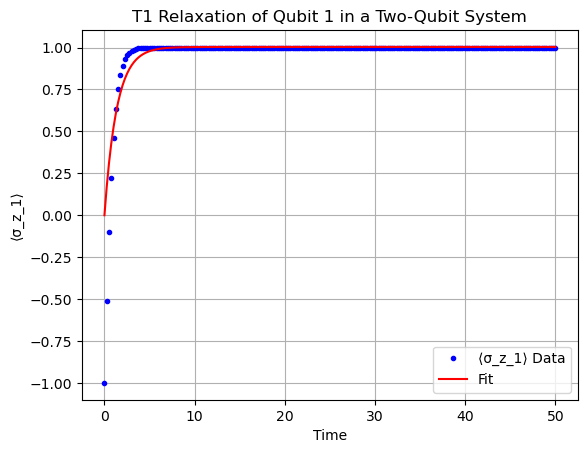

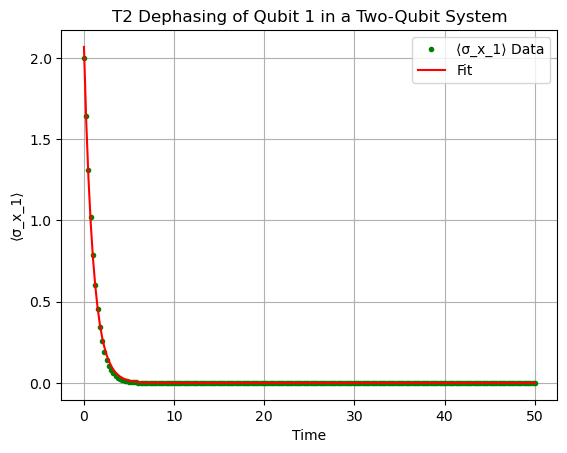

In [168]:
# Defining Basics
import numpy as np
from qutip import mesolve, Qobj, tensor
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

######### Definng quantum states as density matrices #########
Ground_state_1q = Qobj([[1, 0], [0, 0]]) # |0⟩⟨0| (σ_z = +1 eigenstate)
Excited_state_1q = Qobj([[0, 0], [0, 1]]) # |1⟩⟨1| (σ_z = -1 eigenstate)
Ground_state = tensor(Ground_state_1q, Ground_state_1q) # |00⟩⟨00| (σ_z = +1 eigenstate)
Excited_state = tensor(Excited_state_1q, Excited_state_1q) # |11⟩⟨11| (σ_z = -1 eigenstate)


######### Defining Pauli operators #########
sigma_x = Qobj([[0, 1], [1, 0]])
sigma_y = Qobj([[0, -1j], [1j, 0]])
sigma_z = Qobj([[1, 0], [0, -1]])
sigma_minus = Qobj([[0, 1], [0, 0]]) # Was Qobj([[0, 0], [1, 0]])
I = Qobj([[1, 0], [0, 1]]) # 2X2 Identity matrix

######### Defining 2-qubit Pauli operators #########
sx1 = tensor(sigma_x, I) # sigma_x on qubit 1
sx2 = tensor(I, sigma_x) # sigma_x on qubit 2
sy1 = tensor(sigma_y, I) # sigma_y on qubit 1
sy2 = tensor(I, sigma_y) # sigma_y on qubit 2
sz1 = tensor(sigma_z, I) # sigma_z on qubit 1
sz2 = tensor(I, sigma_z) # sigma_z on qubit 2
sm1 = tensor(sigma_minus, I) # sigma_minus on qubit 1
sm2 = tensor(I, sigma_minus) # sigma_minus on qubit 2

######### Density Matrix ######### 
# We can take an arbitrary matrix too but to find T_1 and T_2
# there are 2 inital density matrices that we most care about:
rho_initial_T1 = Qobj(Excited_state) # To find T_1, we let this state relax (Inversion Recovery)
rho_initial_T2 = Qobj(0.5*np.ones((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Start in (|0> + |1>)/sqrt(2) for each qubit.

######### Krauss and Lindblad Operators for Spontaneous Amplitude Damping (Emission Channel) #########
# Parameters
hbar = 1
gamma_AD_1 = 1  # spontaneous emisson rate on qubit 1
gamma_AD_2 = 1  # spontaneous emisson rate on qubit 2
L1_AD = Qobj(np.sqrt(gamma_AD_1*hbar) * (sm1+sm2)) # AD on qubit 1


######### Krauss and Lindblad Operators for Dephasing Channel #########
# Parameters
gamma_DC_1 = 0.1  # Ampl. damping on qubit 1
gamma_DC_2 = 0.1  # Ampl. damping on qubit 2
L1_DC = Qobj(np.sqrt(gamma_DC_1*hbar) * (sz1+sz2)) # DC on qubit 1


######### Solving the Lindblad Master Equation (ODE Solver) #########
T_max = 50
timesteps = 200
tlist = np.linspace(0, T_max, timesteps)

H = Qobj(np.zeros((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Zero Hamiltonian for pure noise

# We read out the qubit 1 (so use sz1, sx1)
result_T1 = mesolve(H, rho_initial_T1, tlist, [L1_AD, L1_DC], [sz1]) # For T1 with both AD and DC
result_T2 = mesolve(H, rho_initial_T2, tlist, [L1_AD, L1_DC], [sx1]) # For T2 with both AD and DC


######### Simulating Dynamics #########
# Extracting T1 and T2
def fit_T1(t, Meq, T1):
    return Meq * (1 - np.exp(-t / T1)) # If I choose 0 as excited state, then use Meq*(-1+np.exp(-t / T1)).

def fit_T2(t, M0, T2):
    return M0 * np.exp(-2 * t / T2)

# Fit data
popt_T1, _ = curve_fit(fit_T1, tlist, result_T1.expect[0], p0=[1.0, 1.0])
popt_T2, _ = curve_fit(fit_T2, tlist, result_T2.expect[0], p0=[1.0, 10.0])
Meq, T1_fit = popt_T1
M0, T2_fit = popt_T2

# Print results
print(f"Estimated T1: {T1_fit:.2f}s")
print(f"Estimated T2: {T2_fit:.2f}s")

# Plot T1 Decay
plt.figure()
plt.plot(tlist, result_T1.expect[0], 'b.', label='⟨σ_z_1⟩ Data')
plt.plot(tlist, fit_T1(tlist, *popt_T1), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_z_1⟩')
plt.title('T1 Relaxation of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

# Plot T2 Decay
plt.figure()
plt.plot(tlist, result_T2.expect[0], 'g.', label='⟨σ_x_1⟩ Data')
plt.plot(tlist, fit_T2(tlist, *popt_T2), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_x_1⟩')
plt.title('T2 Dephasing of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

plt.show()

## 2.4. Correlated AD and DC Noise on 2nd qubit only - same as 2.3 Case

Estimated T1: 1.36s
Estimated T2: 2.02s


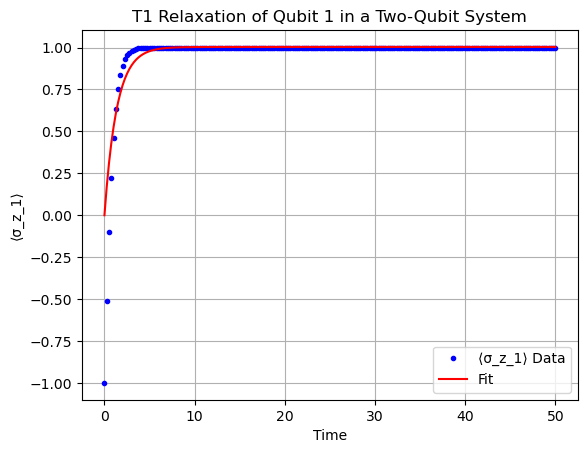

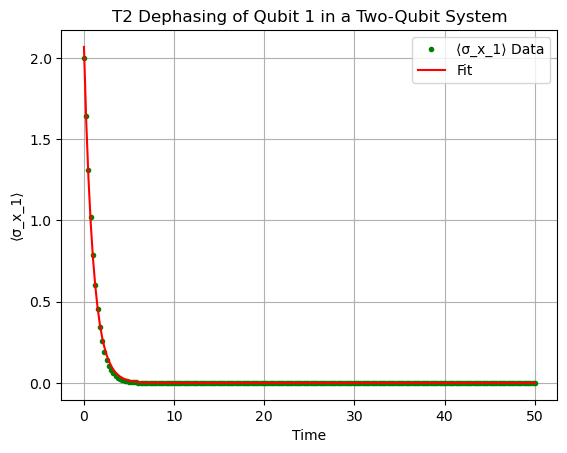

In [173]:
# Defining Basics
import numpy as np
from qutip import mesolve, Qobj, tensor
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

######### Definng quantum states as density matrices #########
Ground_state_1q = Qobj([[1, 0], [0, 0]]) # |0⟩⟨0| (σ_z = +1 eigenstate)
Excited_state_1q = Qobj([[0, 0], [0, 1]]) # |1⟩⟨1| (σ_z = -1 eigenstate)
Ground_state = tensor(Ground_state_1q, Ground_state_1q) # |00⟩⟨00| (σ_z = +1 eigenstate)
Excited_state = tensor(Excited_state_1q, Excited_state_1q) # |11⟩⟨11| (σ_z = -1 eigenstate)


######### Defining Pauli operators #########
sigma_x = Qobj([[0, 1], [1, 0]])
sigma_y = Qobj([[0, -1j], [1j, 0]])
sigma_z = Qobj([[1, 0], [0, -1]])
sigma_minus = Qobj([[0, 1], [0, 0]]) # Was Qobj([[0, 0], [1, 0]])
I = Qobj([[1, 0], [0, 1]]) # 2X2 Identity matrix

######### Defining 2-qubit Pauli operators #########
sx1 = tensor(sigma_x, I) # sigma_x on qubit 1
sx2 = tensor(I, sigma_x) # sigma_x on qubit 2
sy1 = tensor(sigma_y, I) # sigma_y on qubit 1
sy2 = tensor(I, sigma_y) # sigma_y on qubit 2
sz1 = tensor(sigma_z, I) # sigma_z on qubit 1
sz2 = tensor(I, sigma_z) # sigma_z on qubit 2
sm1 = tensor(sigma_minus, I) # sigma_minus on qubit 1
sm2 = tensor(I, sigma_minus) # sigma_minus on qubit 2

######### Density Matrix ######### 
# We can take an arbitrary matrix too but to find T_1 and T_2
# there are 2 inital density matrices that we most care about:
rho_initial_T1 = Qobj(Excited_state) # To find T_1, we let this state relax (Inversion Recovery)
rho_initial_T2 = Qobj(0.5*np.ones((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Start in (|0> + |1>)/sqrt(2) for each qubit.

######### Krauss and Lindblad Operators for Spontaneous Amplitude Damping (Emission Channel) #########
# Parameters
hbar = 1
gamma_AD_1 = 1  # spontaneous emisson rate on qubit 1
gamma_AD_2 = 1  # spontaneous emisson rate on qubit 2
L2_AD = Qobj(np.sqrt(gamma_AD_2*hbar) * (sm1+sm2)) # AD on qubit 1


######### Krauss and Lindblad Operators for Dephasing Channel #########
# Parameters
gamma_DC_1 = 0.1  # Ampl. damping on qubit 1
gamma_DC_2 = 0.1  # Ampl. damping on qubit 2
L2_DC = Qobj(np.sqrt(gamma_DC_2*hbar) * (sz1+sz2)) # DC on qubit 2


######### Solving the Lindblad Master Equation (ODE Solver) #########
T_max = 50
timesteps = 200
tlist = np.linspace(0, T_max, timesteps)

H = Qobj(np.zeros((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Zero Hamiltonian for pure noise

# We read out the qubit 1 (so use sz1, sx1)
result_T1 = mesolve(H, rho_initial_T1, tlist, [L2_AD, L2_DC], [sz1]) # For T1 with both AD and DC
result_T2 = mesolve(H, rho_initial_T2, tlist, [L2_AD, L2_DC], [sx1]) # For T2 with both AD and DC


######### Simulating Dynamics #########
# Extracting T1 and T2
def fit_T1(t, Meq, T1):
    return Meq * (1 - np.exp(-t / T1)) # If I choose 0 as excited state, then use Meq*(-1+np.exp(-t / T1)).

def fit_T2(t, M0, T2):
    return M0 * np.exp(-2 * t / T2)

# Fit data
popt_T1, _ = curve_fit(fit_T1, tlist, result_T1.expect[0], p0=[1.0, 1.0])
popt_T2, _ = curve_fit(fit_T2, tlist, result_T2.expect[0], p0=[1.0, 10.0])
Meq, T1_fit = popt_T1
M0, T2_fit = popt_T2

# Print results
print(f"Estimated T1: {T1_fit:.2f}s")
print(f"Estimated T2: {T2_fit:.2f}s")

# Plot T1 Decay
plt.figure()
plt.plot(tlist, result_T1.expect[0], 'b.', label='⟨σ_z_1⟩ Data')
plt.plot(tlist, fit_T1(tlist, *popt_T1), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_z_1⟩')
plt.title('T1 Relaxation of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

# Plot T2 Decay
plt.figure()
plt.plot(tlist, result_T2.expect[0], 'g.', label='⟨σ_x_1⟩ Data')
plt.plot(tlist, fit_T2(tlist, *popt_T2), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_x_1⟩')
plt.title('T2 Dephasing of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

plt.show()

## 2.5. Correlated AD Noise on both qubits

Estimated T1: 0.66s
Estimated T2: 1.24s


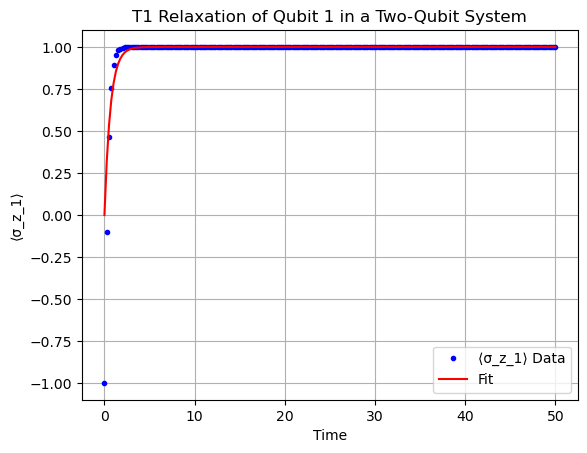

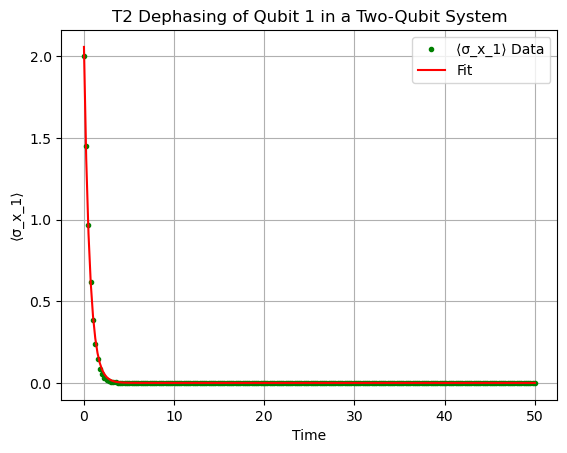

In [179]:
# Defining Basics
import numpy as np
from qutip import mesolve, Qobj, tensor
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

######### Definng quantum states as density matrices #########
Ground_state_1q = Qobj([[1, 0], [0, 0]]) # |0⟩⟨0| (σ_z = +1 eigenstate)
Excited_state_1q = Qobj([[0, 0], [0, 1]]) # |1⟩⟨1| (σ_z = -1 eigenstate)
Ground_state = tensor(Ground_state_1q, Ground_state_1q) # |00⟩⟨00| (σ_z = +1 eigenstate)
Excited_state = tensor(Excited_state_1q, Excited_state_1q) # |11⟩⟨11| (σ_z = -1 eigenstate)


######### Defining Pauli operators #########
sigma_x = Qobj([[0, 1], [1, 0]])
sigma_y = Qobj([[0, -1j], [1j, 0]])
sigma_z = Qobj([[1, 0], [0, -1]])
sigma_minus = Qobj([[0, 1], [0, 0]]) # Was Qobj([[0, 0], [1, 0]])
I = Qobj([[1, 0], [0, 1]]) # 2X2 Identity matrix

######### Defining 2-qubit Pauli operators #########
sx1 = tensor(sigma_x, I) # sigma_x on qubit 1
sx2 = tensor(I, sigma_x) # sigma_x on qubit 2
sy1 = tensor(sigma_y, I) # sigma_y on qubit 1
sy2 = tensor(I, sigma_y) # sigma_y on qubit 2
sz1 = tensor(sigma_z, I) # sigma_z on qubit 1
sz2 = tensor(I, sigma_z) # sigma_z on qubit 2
sm1 = tensor(sigma_minus, I) # sigma_minus on qubit 1
sm2 = tensor(I, sigma_minus) # sigma_minus on qubit 2

######### Density Matrix ######### 
# We can take an arbitrary matrix too but to find T_1 and T_2
# there are 2 inital density matrices that we most care about:
rho_initial_T1 = Qobj(Excited_state) # To find T_1, we let this state relax (Inversion Recovery)
rho_initial_T2 = Qobj(0.5*np.ones((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Start in (|0> + |1>)/sqrt(2) for each qubit.

######### Krauss and Lindblad Operators for Spontaneous Amplitude Damping (Emission Channel) #########
# Parameters
hbar = 1
gamma_AD_1 = 1  # spontaneous emisson rate on qubit 1
gamma_AD_2 = 1  # spontaneous emisson rate on qubit 2
L1_AD = Qobj(np.sqrt(gamma_AD_1*hbar) * (sm1+sm2)) # AD on qubit 1
L2_AD = Qobj(np.sqrt(gamma_AD_2*hbar) * (sm1+sm2)) # AD on qubit 2

######### Solving the Lindblad Master Equation (ODE Solver) #########
T_max = 50
timesteps = 200
tlist = np.linspace(0, T_max, timesteps)

H = Qobj(np.zeros((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Zero Hamiltonian for pure noise

# We read out the qubit 1 (so use sz1, sx1)
result_T1 = mesolve(H, rho_initial_T1, tlist, [L1_AD, L2_AD], [sz1]) # For T1 with both AD and DC
result_T2 = mesolve(H, rho_initial_T2, tlist, [L1_AD, L2_AD], [sx1]) # For T2 with both AD and DC


######### Simulating Dynamics #########
# Extracting T1 and T2
def fit_T1(t, Meq, T1):
    return Meq * (1 - np.exp(-t / T1)) # If I choose 0 as excited state, then use Meq*(-1+np.exp(-t / T1)).

def fit_T2(t, M0, T2):
    return M0 * np.exp(-2 * t / T2)

# Fit data
popt_T1, _ = curve_fit(fit_T1, tlist, result_T1.expect[0], p0=[1.0, 1.0])
popt_T2, _ = curve_fit(fit_T2, tlist, result_T2.expect[0], p0=[1.0, 10.0])
Meq, T1_fit = popt_T1
M0, T2_fit = popt_T2

# Print results
print(f"Estimated T1: {T1_fit:.2f}s")
print(f"Estimated T2: {T2_fit:.2f}s")

# Plot T1 Decay
plt.figure()
plt.plot(tlist, result_T1.expect[0], 'b.', label='⟨σ_z_1⟩ Data')
plt.plot(tlist, fit_T1(tlist, *popt_T1), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_z_1⟩')
plt.title('T1 Relaxation of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

# Plot T2 Decay
plt.figure()
plt.plot(tlist, result_T2.expect[0], 'g.', label='⟨σ_x_1⟩ Data')
plt.plot(tlist, fit_T2(tlist, *popt_T2), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_x_1⟩')
plt.title('T2 Dephasing of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

plt.show()

## 2.6. Correlated AD Noise on 1st qubit only

Estimated T1: 1.36s
Estimated T2: 2.45s


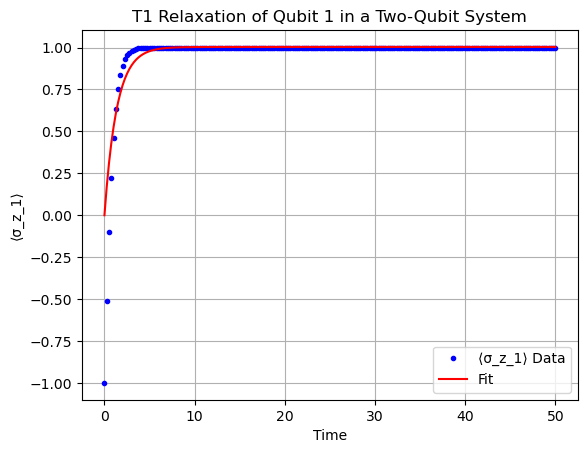

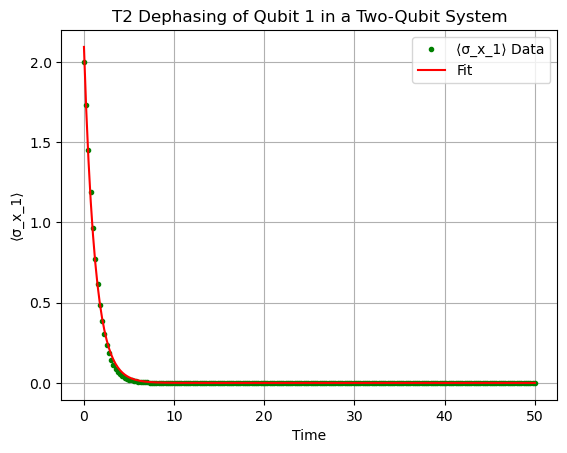

In [185]:
# Defining Basics
import numpy as np
from qutip import mesolve, Qobj, tensor
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

######### Definng quantum states as density matrices #########
Ground_state_1q = Qobj([[1, 0], [0, 0]]) # |0⟩⟨0| (σ_z = +1 eigenstate)
Excited_state_1q = Qobj([[0, 0], [0, 1]]) # |1⟩⟨1| (σ_z = -1 eigenstate)
Ground_state = tensor(Ground_state_1q, Ground_state_1q) # |00⟩⟨00| (σ_z = +1 eigenstate)
Excited_state = tensor(Excited_state_1q, Excited_state_1q) # |11⟩⟨11| (σ_z = -1 eigenstate)


######### Defining Pauli operators #########
sigma_x = Qobj([[0, 1], [1, 0]])
sigma_y = Qobj([[0, -1j], [1j, 0]])
sigma_z = Qobj([[1, 0], [0, -1]])
sigma_minus = Qobj([[0, 1], [0, 0]]) # Was Qobj([[0, 0], [1, 0]])
I = Qobj([[1, 0], [0, 1]]) # 2X2 Identity matrix

######### Defining 2-qubit Pauli operators #########
sx1 = tensor(sigma_x, I) # sigma_x on qubit 1
sx2 = tensor(I, sigma_x) # sigma_x on qubit 2
sy1 = tensor(sigma_y, I) # sigma_y on qubit 1
sy2 = tensor(I, sigma_y) # sigma_y on qubit 2
sz1 = tensor(sigma_z, I) # sigma_z on qubit 1
sz2 = tensor(I, sigma_z) # sigma_z on qubit 2
sm1 = tensor(sigma_minus, I) # sigma_minus on qubit 1
sm2 = tensor(I, sigma_minus) # sigma_minus on qubit 2

######### Density Matrix ######### 
# We can take an arbitrary matrix too but to find T_1 and T_2
# there are 2 inital density matrices that we most care about:
rho_initial_T1 = Qobj(Excited_state) # To find T_1, we let this state relax (Inversion Recovery)
rho_initial_T2 = Qobj(0.5*np.ones((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Start in (|0> + |1>)/sqrt(2) for each qubit.

######### Krauss and Lindblad Operators for Spontaneous Amplitude Damping (Emission Channel) #########
# Parameters
hbar = 1
gamma_AD_1 = 1  # spontaneous emisson rate on qubit 1
gamma_AD_2 = 1  # spontaneous emisson rate on qubit 2
L1_AD = Qobj(np.sqrt(gamma_AD_1*hbar) * (sm1+sm2)) # AD on qubit 1

######### Solving the Lindblad Master Equation (ODE Solver) #########
T_max = 50
timesteps = 200
tlist = np.linspace(0, T_max, timesteps)

H = Qobj(np.zeros((4, 4), dtype=complex), dims=[[2, 2], [2, 2]]) # Zero Hamiltonian for pure noise

# We read out the qubit 1 (so use sz1, sx1)
result_T1 = mesolve(H, rho_initial_T1, tlist, [L1_AD], [sz1]) # For T1 with both AD and DC
result_T2 = mesolve(H, rho_initial_T2, tlist, [L1_AD], [sx1]) # For T2 with both AD and DC


######### Simulating Dynamics #########
# Extracting T1 and T2
def fit_T1(t, Meq, T1):
    return Meq * (1 - np.exp(-t / T1)) # If I choose 0 as excited state, then use Meq*(-1+np.exp(-t / T1)).

def fit_T2(t, M0, T2):
    return M0 * np.exp(-2 * t / T2)

# Fit data
popt_T1, _ = curve_fit(fit_T1, tlist, result_T1.expect[0], p0=[1.0, 1.0])
popt_T2, _ = curve_fit(fit_T2, tlist, result_T2.expect[0], p0=[1.0, 10.0])
Meq, T1_fit = popt_T1
M0, T2_fit = popt_T2

# Print results
print(f"Estimated T1: {T1_fit:.2f}s")
print(f"Estimated T2: {T2_fit:.2f}s")

# Plot T1 Decay
plt.figure()
plt.plot(tlist, result_T1.expect[0], 'b.', label='⟨σ_z_1⟩ Data')
plt.plot(tlist, fit_T1(tlist, *popt_T1), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_z_1⟩')
plt.title('T1 Relaxation of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

# Plot T2 Decay
plt.figure()
plt.plot(tlist, result_T2.expect[0], 'g.', label='⟨σ_x_1⟩ Data')
plt.plot(tlist, fit_T2(tlist, *popt_T2), 'r-', label='Fit')
plt.xlabel('Time')
plt.ylabel('⟨σ_x_1⟩')
plt.title('T2 Dephasing of Qubit 1 in a Two-Qubit System')
plt.legend()
plt.grid(True)

plt.show()

# 3. Two-Qubit Gates (iSWAP and CZ)
## 3.1. Two-Qubit Gates (iSWAP and CZ) via Fixed Coupler

## 3.2. Two-Qubit Gates (iSWAP and CZ) via Tunable Coupler